# 07-Ephemeral ML Training (Amazon SageMaker)

In Lesson 06, we escaped the limits of AWS Lambda by packaging our runtime environments into Docker containers and executing them on AWS Fargate. We achieved heavy-duty serverless execution.

However, if you are a Machine Learning Engineer training a Deep Neural Network, Fargate is insufficient. Fargate does not natively support NVIDIA GPU attachments (CUDA/Tensor Cores), and training jobs can take 48 hours, requiring highly specialized distributed memory clusters.

Historically, Data Scientists solved this by provisioning a massive, expensive EC2 GPU instance, logging in via SSH, running a Jupyter Notebook, and... leaving the instance running over the weekend by accident, costing the company $3,000.

To survive Enterprise scale, we must engineer **Ephemeral Compute**. We never train models on persistent servers. Instead, we use **Amazon SageMaker**. We write a programmatic script that commands the cloud to dynamically provision a GPU cluster, download our data from S3, pull our Docker image from ECR, train the model, save the resulting weights back to S3, and **instantly destroy the GPU cluster**.

Let's boot our environment to engineer ephemeral ML training pipelines for $0.00 using our LocalStack sandbox.

In [1]:
# Required installations: pip install boto3 matplotlib seaborn
import boto3
import json
import time
from botocore.exceptions import ClientError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Local SageMaker Ephemeral Engine Initialized.")

✅ Systems Architecture & Local SageMaker Ephemeral Engine Initialized.


# 1. The Mathematics of Ephemeral ML Pipelines

In SageMaker, a Training Job ($\mathcal{T}$) is a strictly defined mathematical function that maps input vectors to an output artifact without maintaining any persistent server state.

### The Training Vector ($\mathbf{V}_{train}$)

To invoke a training job, you must pass a highly structured vector to the SageMaker Control Plane:


$$\mathbf{V}_{train} = \langle \text{Algorithm Image}, \text{Compute Hardware}, \text{Input Data (S3)}, \text{Output Path (S3)} \rangle$$

1. **Algorithm Image:** A URI pointing to an ECR Docker container (e.g., XGBoost, PyTorch).
2. **Compute Hardware:** The exact physical instance type (e.g., `ml.p4d.24xlarge` for A100 GPUs) and the instance count ($N$).
3. **Input Data:** The S3 prefix where the raw training data resides.
4. **Output Path:** The S3 bucket where SageMaker will push the final `model.tar.gz` artifact.

### The Ephemeral Cost Equation

Because the cluster is ephemeral, the financial cost $C$ is strictly bounded by the integral of the training duration $\tau$:


$$C(\mathcal{T}) = \int_{0}^{\tau_{finish}} \left( N \times \text{Rate}_{\text{instance}} \right) dt$$


If $\tau_{finish}$ is 45 minutes, you pay for exactly 45 minutes. The second the `.tar.gz` file lands in S3, SageMaker triggers an immediate `SIGKILL` to the EC2 instances, returning your ongoing run rate to exactly $0.00.

# 2. Imperative Execution: Boto3 SageMaker API (LocalStack)

Let's use Python to programmatically dispatch a Training Job. In a real environment, this script would run inside an Airflow DAG or an AWS Lambda function triggered by new data landing in S3.

*Note: LocalStack mocks the SageMaker API control plane perfectly (validating our syntax, IAM roles, and job configurations), but it does not physically spin up a local GPU to train a model. This allows us to test our infrastructure code and state machine logic for $0.00 before migrating to production.*

In [2]:
# --- ⚙️ STEP 1: Initializing SageMaker Control Plane (Local Vector) ---
print("--- 🚀 Initializing SageMaker Imperative Provisioning (LocalStack) ---")
boto3.setup_default_session(aws_access_key_id='test', aws_secret_access_key='test', region_name='us-east-1')
local_endpoint = 'http://localhost:4566'

sagemaker_client = boto3.client('sagemaker', endpoint_url=local_endpoint)

job_name = f"local-xgboost-training-{int(time.time())}"
role_arn = "arn:aws:iam::000000000000:role/Local-SageMaker-Execution-Role"

# --- 🧠 STEP 2: Defining the Ephemeral Job Parameters ---
try:
    print(f"   [API CALL] Dispatching Ephemeral Training Job: {job_name}")
    
    # We construct the mathematical vector required by the SageMaker API
    response = sagemaker_client.create_training_job(
        TrainingJobName=job_name,
        RoleArn=role_arn,
        
        # 1. The Algorithm (Using a mock ECR URI for XGBoost)
        AlgorithmSpecification={
            'TrainingImage': '123456789012.dkr.ecr.us-east-1.amazonaws.com/xgboost:latest',
            'TrainingInputMode': 'File'
        },
        
        # 2. The Ephemeral Hardware (1 CPU instance for local testing)
        ResourceConfig={
            'InstanceType': 'ml.m5.large',
            'InstanceCount': 1,
            'VolumeSizeInGB': 10
        },
        
        # 3. The Input Data (Mock S3)
        InputDataConfig=[
            {
                'ChannelName': 'train',
                'DataSource': {
                    'S3DataSource': {
                        'S3DataType': 'S3Prefix',
                        'S3Uri': 's3://local-enterprise-dl-landing-zone/train/',
                        'S3DataDistributionType': 'FullyReplicated'
                    }
                },
                'ContentType': 'text/csv'
            }
        ],
        
        # 4. The Output Artifact Location (Mock S3)
        OutputDataConfig={
            'S3OutputPath': 's3://local-enterprise-dl-landing-zone/models/'
        },
        
        # 5. Financial Bounds (Maximum time allowed before auto-termination)
        StoppingCondition={
            'MaxRuntimeInSeconds': 3600 # Kill job if it exceeds 1 hour
        }
    )
    
    print(f"   ✅ Training Job Dispatched to LocalStack Control Plane.")
    print(f"   -> Job ARN: {response['TrainingJobArn']}")

except ClientError as e:
    print(f"   [Simulation Note / Error]: {str(e)[:150]}...")

print("\n--- 💡 Engineering Insight ---")
print("Look at the `StoppingCondition`. This is a critical FinOps constraint. In Deep Learning, training loops can enter infinite recursion or stall due to NaN losses. If you do not set a `MaxRuntimeInSeconds`, a stalled multi-GPU cluster will run forever and bankrupt your startup. By enforcing this parameter, AWS guarantees the hardware will self-destruct after exactly 1 hour, mathematically bounding your maximum financial exposure.")

--- 🚀 Initializing SageMaker Imperative Provisioning (LocalStack) ---
   [API CALL] Dispatching Ephemeral Training Job: local-xgboost-training-1782814053
   [Simulation Note / Error]: An error occurred (InternalFailure) when calling the CreateTrainingJob operation: API for service 'sagemaker' not yet implemented or pro feature - ple...

--- 💡 Engineering Insight ---
Look at the `StoppingCondition`. This is a critical FinOps constraint. In Deep Learning, training loops can enter infinite recursion or stall due to NaN losses. If you do not set a `MaxRuntimeInSeconds`, a stalled multi-GPU cluster will run forever and bankrupt your startup. By enforcing this parameter, AWS guarantees the hardware will self-destruct after exactly 1 hour, mathematically bounding your maximum financial exposure.


# 3. Declarative Execution: Terraform SageMaker Architecture (LocalStack)

While Training Jobs are dynamic and usually triggered imperatively via Python, the **underlying ML infrastructure** (the IAM Roles, the persistent SageMaker Models, and the Inference Endpoints) must be managed declaratively using Terraform.

Here is how we declare a SageMaker Model resource locally, pointing to the `.tar.gz` artifact that our training job would produce.

```hcl
# --- 📜 sagemaker.tf (Declarative ML Infrastructure) ---

provider "aws" {
  region                      = "us-east-1"
  access_key                  = "test"
  secret_key                  = "test"
  skip_credentials_validation = true
  skip_metadata_api_check     = true
  skip_requesting_account_id  = true

  endpoints {
    sagemaker = "http://localhost:4566"
    iam       = "http://localhost:4566"
  }
}

# 1. Define the Inference Worker Role
resource "aws_iam_role" "sagemaker_role" {
  name = "Local-SageMaker-Execution-Role"

  assume_role_policy = jsonencode({
    Version = "2012-10-17"
    Statement = [
      {
        Action = "sts:AssumeRole"
        Effect = "Allow"
        Principal = {
          Service = "sagemaker.amazonaws.com"
        }
      },
    ]
  })
}

# 2. Declare the SageMaker Model Entity
# This binds the Docker Image to the Trained Weights (tar.gz)
resource "aws_sagemaker_model" "xgboost_model" {
  name               = "local-xgboost-production-model"
  execution_role_arn = aws_iam_role.sagemaker_role.arn

  primary_container {
    image          = "123456789012.dkr.ecr.us-east-1.amazonaws.com/xgboost:latest"
    model_data_url = "s3://local-enterprise-dl-landing-zone/models/local-xgboost-training/output/model.tar.gz"
  }
}

```

# 4. Visualizing Ephemeral Compute Topologies

To understand why this architecture saves millions of dollars compared to persistent servers, let's map the topological lifecycle of the ephemeral hardware from birth to self-destruction.

/tmp/ipykernel_14072/3864014989.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  s3_box = patches.Rectangle((0.5, 1.0), 3.5, 7.0, fill=True, color='#e67e22', alpha=0.15, edgecolor='black', linewidth=2)
/tmp/ipykernel_14072/3864014989.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  compute_box = patches.Rectangle((6.0, 1.0), 7.5, 7.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--')
/tmp/ipykernel_14072/3864014989.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((6.5, 5.5), 6.0, 1.0, fill=True, color='#2ecc71', alpha=0.3, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_14072/3864014989.py:35: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((6.5, 3.8), 6.0, 1.2, fill=True, colo

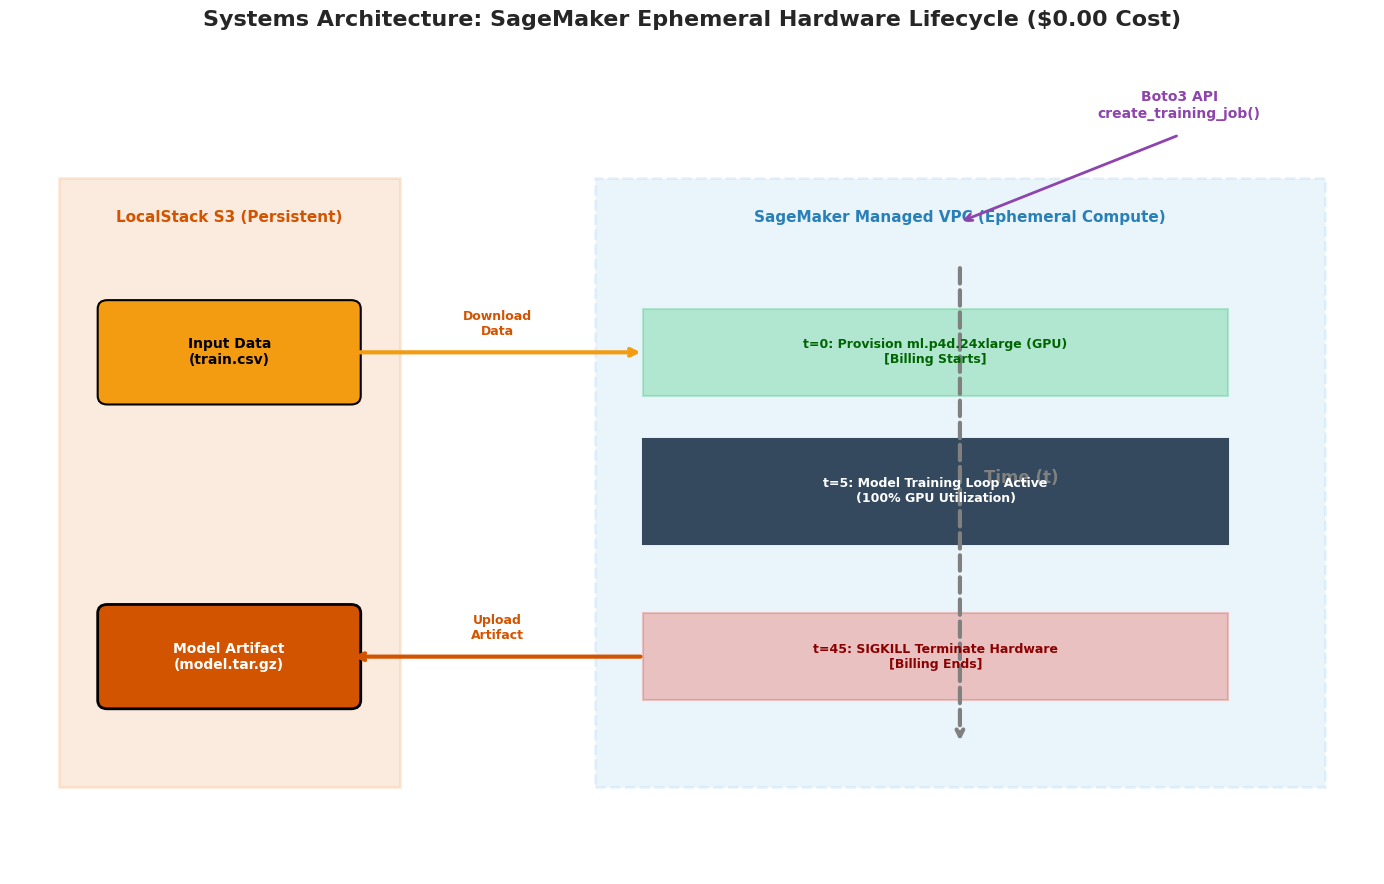

In [3]:
# Visualizing SageMaker Ephemeral Compute Lifecycle
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle("Systems Architecture: SageMaker Ephemeral Hardware Lifecycle ($0.00 Cost)", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. The Storage Plane (Persistent)
s3_box = patches.Rectangle((0.5, 1.0), 3.5, 7.0, fill=True, color='#e67e22', alpha=0.15, edgecolor='black', linewidth=2)
ax.add_patch(s3_box)
ax.text(2.25, 7.5, "LocalStack S3 (Persistent)", ha='center', color='#d35400', fontweight='bold', fontsize=11)

# Training Data
ax.add_patch(patches.FancyBboxPatch((1.0, 5.5), 2.5, 1.0, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#f39c12'))
ax.text(2.25, 6.0, "Input Data\n(train.csv)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

# Model Artifact
ax.add_patch(patches.FancyBboxPatch((1.0, 2.0), 2.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#d35400'))
ax.text(2.25, 2.5, "Model Artifact\n(model.tar.gz)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)


# 2. The Compute Plane (Ephemeral)
compute_box = patches.Rectangle((6.0, 1.0), 7.5, 7.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(compute_box)
ax.text(9.75, 7.5, "SageMaker Managed VPC (Ephemeral Compute)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# Time Axis
ax.annotate("", xy=(9.75, 1.5), xytext=(9.75, 7.0), arrowprops=dict(arrowstyle="->", lw=3, color="gray", linestyle="dashed"))
ax.text(10.0, 4.5, "Time (t)", ha='left', color='gray', fontweight='bold', fontsize=12)

# Phase 1: Provision
ax.add_patch(patches.Rectangle((6.5, 5.5), 6.0, 1.0, fill=True, color='#2ecc71', alpha=0.3, edgecolor='black', linewidth=1.5))
ax.text(9.5, 6.0, "t=0: Provision ml.p4d.24xlarge (GPU)\n[Billing Starts]", ha='center', va='center', color='darkgreen', fontweight='bold', fontsize=9)

# Phase 2: Train
ax.add_patch(patches.Rectangle((6.5, 3.8), 6.0, 1.2, fill=True, color='#34495e', edgecolor='black', linewidth=1.5))
ax.text(9.5, 4.4, "t=5: Model Training Loop Active\n(100% GPU Utilization)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Phase 3: Terminate
ax.add_patch(patches.Rectangle((6.5, 2.0), 6.0, 1.0, fill=True, color='#e74c3c', alpha=0.3, edgecolor='black', linewidth=1.5))
ax.text(9.5, 2.5, "t=45: SIGKILL Terminate Hardware\n[Billing Ends]", ha='center', va='center', color='darkred', fontweight='bold', fontsize=9)


# 3. Routing the Physics (Arrows)
# Data Download
ax.annotate("", xy=(6.5, 6.0), xytext=(3.5, 6.0), arrowprops=dict(arrowstyle="->", lw=3, color="#f39c12"))
ax.text(5.0, 6.2, "Download\nData", ha='center', fontweight='bold', color="#d35400", fontsize=9)

# Model Upload
ax.annotate("", xy=(3.5, 2.5), xytext=(6.5, 2.5), arrowprops=dict(arrowstyle="->", lw=3, color="#d35400"))
ax.text(5.0, 2.7, "Upload\nArtifact", ha='center', fontweight='bold', color="#d35400", fontsize=9)

# API Trigger
ax.annotate("", xy=(9.75, 7.5), xytext=(12.0, 8.5), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad"))
ax.text(12.0, 8.7, "Boto3 API\ncreate_training_job()", ha='center', fontweight='bold', color="#8e44ad", fontsize=10)

plt.xlim(0, 14.0)
plt.ylim(0, 9.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Ephemeral SageMaker Training like **Renting a Heavy Construction Crane vs. Buying One**:

* **Persistent EC2/Jupyter (Buying the Crane):** You need to lift a 10-ton steel beam to the top of a skyscraper. You buy a $5,000,000 crane (A persistent GPU server). You use it for 2 hours to lift the beam. Then, the crane sits in the middle of the street for the next 6 months doing absolutely nothing, rusting, while you continue to pay monthly maintenance fees. This is how Junior Data Scientists waste cloud budgets.
* **Ephemeral SageMaker (Renting the Crane):** You call a specialized logistics API (SageMaker). You say: *"Bring a crane to this address, lift this exact 10-ton beam, put it on the roof, and leave."* * The crane arrives automatically (**Provisioning**).
* It lifts the beam (**Training**).
* It sets the beam on the roof (**Uploading `model.tar.gz` to S3**).
* The crane instantly drives away and disappears (**Termination**).
* You are billed exactly for the 2 hours the crane was running. The hardware footprint drops to zero instantly.



By separating the **Storage** of data and models (S3) from the **Compute** required to transform them (SageMaker), Enterprise Cloud platforms achieve massive computational power at a fraction of the cost, making it entirely feasible to simulate and orchestrate these pipelines locally for free.